<a href="https://colab.research.google.com/github/canasep/mackprojeto3/blob/main/PROJETO_APLICADO_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistema de Recomendação de Cursos Online — KNN Content-Based
## **Universidade Presbiteriana Mackenzie**
### Projeto Aplicado III


#### Eduardo Pinheiro Canas
#### Hugo de Moraes Holzer
#### Luiz Rodrigo Alves Vergino

---
**Dataset:** [Coursera Courses Dataset 2021 — Kaggle](https://www.kaggle.com/datasets/khusheekapoor/coursera-courses-dataset-2021)  
**Algoritmo:** K-Nearest Neighbors com TF-IDF (Filtragem Baseada em Conteúdo)  
**ODS:** ODS 4 — Educação de Qualidade | ODS 8 — Trabalho Decente

## 1. Instalação e Importações

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 12

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento dos Dados
Carregamento dos daddos diretamente do Kaggle via API.
> https://www.kaggle.com/datasets/khusheekapoor/coursera-courses-dataset-2021  


In [43]:
!kaggle datasets download -d khusheekapoor/coursera-courses-dataset-2021 --unzip

# Carregamento
df = pd.read_csv('Coursera.csv')

print(f'Shape: {df.shape}')
print(f'\nColunas: {list(df.columns)}')
display(df.head())

Dataset URL: https://www.kaggle.com/datasets/khusheekapoor/coursera-courses-dataset-2021
License(s): unknown
100% 1.65M/1.65M [00:00<00:00, 25.4MB/s]

Shape: (3522, 7)

Colunas: ['Course Name', 'University', 'Difficulty Level', 'Course Rating', 'Course URL', 'Course Description', 'Skills']


,Course Name,University,Difficulty Level,Course Rating,Course URL,Course Description,Skills
0,Write A Feature Length Screenplay For Film Or ...,Michigan State University,Beginner,4.8,https://www.coursera.org/learn/write-a-feature...,Write a Full Length Feature Film Script In th...,Drama Comedy peering screenwriting film D...
1,Business Strategy: Business Model Canvas Analy...,Coursera Project Network,Beginner,4.8,https://www.coursera.org/learn/canvas-analysis...,"By the end of this guided project, you will be...",Finance business plan persona (user experien...
2,Silicon Thin Film Solar Cells,�cole Polytechnique,Advanced,4.1,https://www.coursera.org/learn/silicon-thin-fi...,This course consists of a general presentation...,chemistry physics Solar Energy film lambda...
3,Finance for Managers,IESE Business School,Intermediate,4.8,https://www.coursera.org/learn/operational-fin...,"When it comes to numbers, there is always more...",accounts receivable dupont analysis analysis...
4,Retrieve Data using Single-Table SQL Queries,Coursera Project Network,Beginner,4.6,https://www.coursera.org/learn/single-table-sq...,In this course you�ll learn how to effectively...,Data Analysis select (sql) database manageme...


In [44]:
# Padronizar nomes das colunas
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Colunas padronizadas:', list(df.columns))

# Renomear para nomes curtos
col_map = {
    'course_name':       'name',
    'university':        'university',
    'difficulty_level':  'difficulty',
    'course_rating':     'rating',
    'course_url':        'url',
    'course_description':'description',
    'skills':            'skills'
}
# Tentar remapear (tolerante a variações de nome)
actual = {c: c for c in df.columns}
for std, short in col_map.items():
    for col in df.columns:
        if std in col or short in col:
            actual[col] = short
            break
df = df.rename(columns=actual)

print('\nColunas finais:', list(df.columns))
print(f'\nValores nulos:')
print(df.isnull().sum())

Colunas padronizadas: ['course_name', 'university', 'difficulty_level', 'course_rating', 'course_url', 'course_description', 'skills']

Colunas finais: ['name', 'university', 'difficulty', 'rating', 'url', 'description', 'skills']

Valores nulos:
name           0
university     0
difficulty     0
rating         0
url            0
description    0
skills         0
dtype: int64


## 3. Análise Exploratória (EDA)

In [45]:
print('=== ESTATÍSTICAS DESCRITIVAS ===')
display(df.describe(include='all').T)

print(f'\nTotal de cursos: {len(df):,}')
print(f'Universidades únicas: {df["university"].nunique()}')
print(f'Níveis de dificuldade: {df["difficulty"].unique()}')

=== ESTATÍSTICAS DESCRITIVAS ===


,count,unique,top,freq
name,3522,3416,Google Cloud Platform Fundamentals: Core Infra...,8
university,3522,184,Coursera Project Network,562
difficulty,3522,5,Beginner,1444
rating,3522,31,4.7,740
url,3522,3424,https://www.coursera.org/learn/gcp-fundamentals,8
description,3522,3397,This course introduces you to important concep...,8
skills,3522,3424,Google Cloud Platform Big Data Cloud Infrast...,8



Total de cursos: 3,522
Universidades únicas: 184
Níveis de dificuldade: ['Beginner' 'Advanced' 'Intermediate' 'Not Calibrated' 'Conversant']


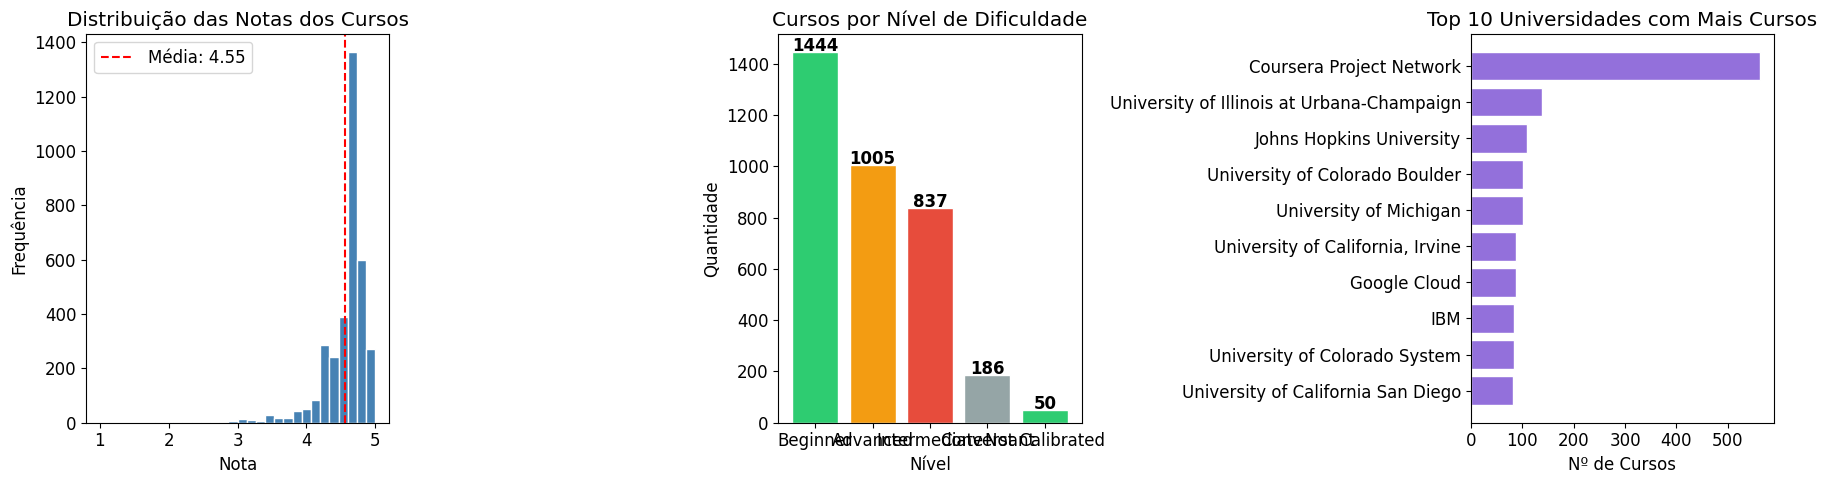

In [46]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribuição de ratings
axes[0].hist(df['rating'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['rating'].mean(), color='red', linestyle='--', label=f'Média: {df["rating"].mean():.2f}')
axes[0].set_title('Distribuição das Notas dos Cursos')
axes[0].set_xlabel('Nota')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# 2. Cursos por nível de dificuldade
diff_counts = df['difficulty'].value_counts()
colors = ['#2ecc71','#f39c12','#e74c3c','#95a5a6']
axes[1].bar(diff_counts.index, diff_counts.values, color=colors[:len(diff_counts)], edgecolor='white')
axes[1].set_title('Cursos por Nível de Dificuldade')
axes[1].set_xlabel('Nível')
axes[1].set_ylabel('Quantidade')
for i, v in enumerate(diff_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 3. Top 10 universidades
top_uni = df['university'].value_counts().nlargest(10)
axes[2].barh(top_uni.index[::-1], top_uni.values[::-1], color='mediumpurple', edgecolor='white')
axes[2].set_title('Top 10 Universidades com Mais Cursos')
axes[2].set_xlabel('Nº de Cursos')

plt.tight_layout()
plt.show()

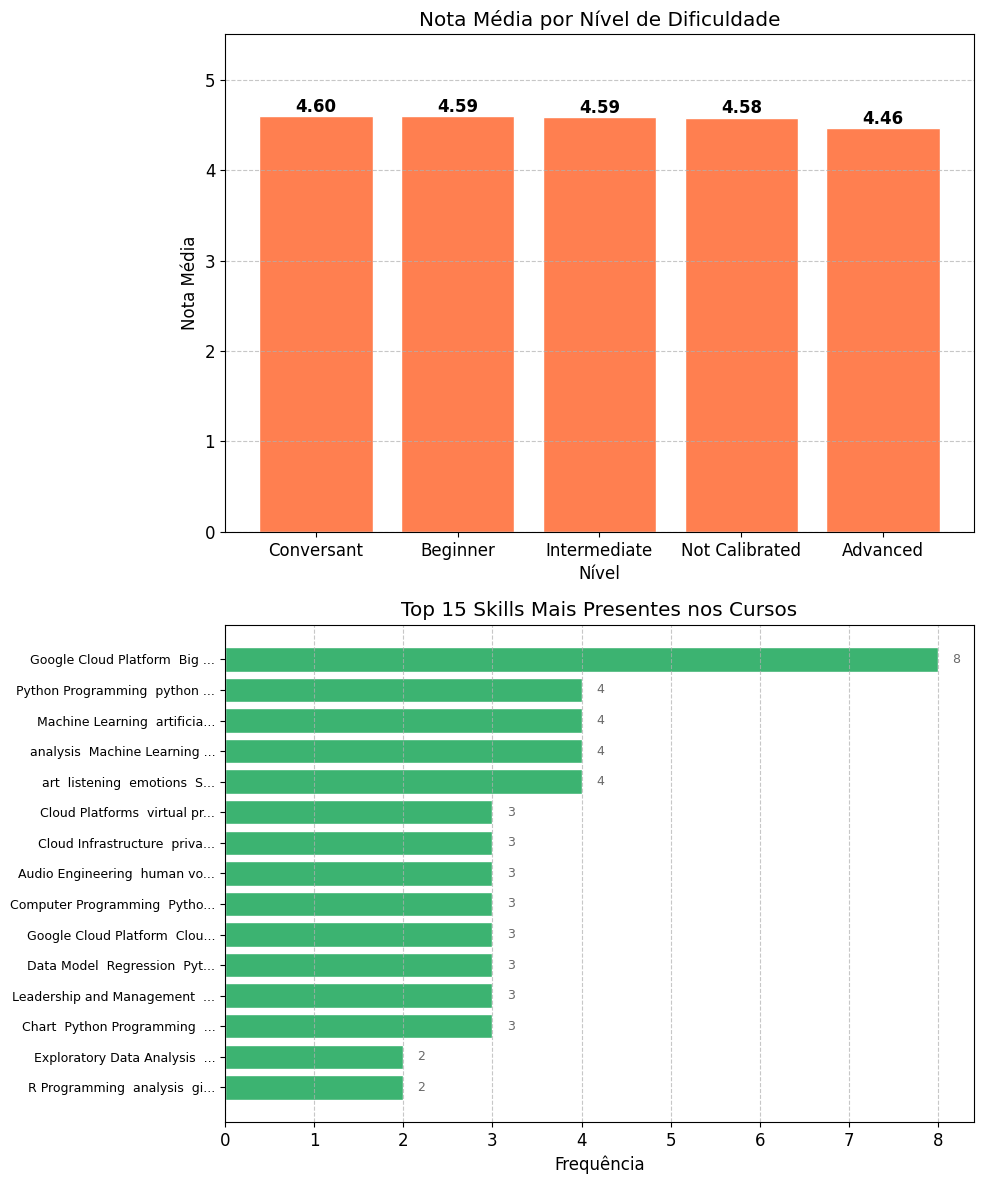

Total de skills únicas: 3424


In [47]:
# Nota média por nível de dificuldade
fig, axes = plt.subplots(2, 1, figsize=(10, 12)) # Changed to 2 rows, 1 column for stacked plots, adjusted figure size

rating_by_diff = df.groupby('difficulty')['rating'].mean().sort_values(ascending=False)
axes[0].bar(rating_by_diff.index, rating_by_diff.values, color='coral', edgecolor='white')
axes[0].set_title('Nota Média por Nível de Dificuldade')
axes[0].set_xlabel('Nível')
axes[0].set_ylabel('Nota Média')
axes[0].set_ylim(0, 5.5)
for i, v in enumerate(rating_by_diff.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.7) # Adiciona grade ao primeiro gráfico

# Top skills mais comuns
all_skills = df['skills'].dropna().str.split(',').explode().str.strip()
top_skills = all_skills.value_counts().nlargest(15)

# Truncate long skill names for better readability on y-axis
y_labels = [label if len(label) < 30 else label[:27] + '...' for label in top_skills.index[::-1]]

bars = axes[1].barh(y_labels, top_skills.values[::-1], color='mediumseagreen', edgecolor='white') # Use truncated labels
axes[1].set_title('Top 15 Skills Mais Presentes nos Cursos')
axes[1].set_xlabel('Frequência')
axes[1].tick_params(axis='y', labelsize=9) # Adjust font size for y-axis labels

# Adiciona rótulos de valor ao gráfico de barras horizontais
for bar in bars:
    width = bar.get_width()
    # Position text slightly after the bar, relative to its width or a fixed small offset
    axes[1].text(width + (top_skills.values.max() * 0.02), # Dynamic offset based on max frequency
                 bar.get_y() + bar.get_height()/2,
                 f'{int(width)}', va='center', ha='left', fontsize=9, color='dimgray')
axes[1].grid(axis='x', linestyle='--', alpha=0.7) # Adiciona grade ao segundo gráfico

plt.tight_layout()
plt.show()

print(f'Total de skills únicas: {all_skills.nunique()}')

## 4. Pré-processamento e Engenharia de Features
> Combinamos `skills`, `description` e `difficulty` em um único campo textual para representar cada curso. Essa é a base para a vetorização TF-IDF.

In [48]:
def limpar_texto(texto):
    """Remove caracteres especiais, normaliza espaços e converte para minúsculas."""
    if pd.isna(texto):
        return ''
    texto = str(texto).lower()
    texto = re.sub(r'[^a-z0-9\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Preencher nulos
df['skills']      = df['skills'].fillna('')
df['description'] = df['description'].fillna('')
df['difficulty']  = df['difficulty'].fillna('Mixed')
df['rating']      = df['rating'].fillna(df['rating'].median())

# Campo combinado: skills (peso duplo) + description + difficulty
# Repetimos skills 2x para aumentar seu peso relativo no TF-IDF
df['features'] = (
    df['skills'].apply(limpar_texto) + ' ' +
    df['skills'].apply(limpar_texto) + ' ' +   # peso duplo
    df['difficulty'].apply(limpar_texto) + ' ' +
    df['description'].apply(limpar_texto)
)

print('✅ Campo "features" criado!')
print(f'\nExemplo de features (curso 0):')
print(df['features'].iloc[0][:300], '...')

✅ Campo "features" criado!

Exemplo de features (curso 0):
drama comedy peering screenwriting film document review dialogue creative writing writing unix shells arts and humanities music and art drama comedy peering screenwriting film document review dialogue creative writing writing unix shells arts and humanities music and art beginner write a full length ...


## 5. Vetorização TF-IDF

## O que é Vetorização TF-IDF?

**TF-IDF** (Term Frequency-Inverse Document Frequency) é uma técnica estatística de ponderação que reflete a importância de uma palavra em um documento em relação a uma coleção (corpus) de documentos. É amplamente utilizada em recuperação de informação e mineração de texto.

### Como Funciona?

O TF-IDF é composto por dois termos:

1.  **Frequência do Termo (TF - Term Frequency)**:
    *   Mede a frequência com que uma palavra (termo) aparece em um determinado documento.
    *   Quanto mais vezes uma palavra aparece em um documento, maior sua importância *dentro daquele documento*.
    *   Geralmente é normalizado para evitar que documentos mais longos tenham valores de TF artificialmente altos.
    *   Fórmula comum: `TF(t, d) = (Número de vezes que o termo 't' aparece no documento 'd') / (Número total de termos no documento 'd')`.

2.  **Frequência Inversa do Documento (IDF - Inverse Document Frequency)**:
    *   Mede o quão rara ou comum uma palavra é *em toda a coleção de documentos*.
    *   Palavras que aparecem em muitos documentos (como artigos, preposições - 'a', 'o', 'de') tendem a ser menos informativas. O IDF penaliza essas palavras comuns, dando-lhes um peso menor.
    *   Palavras que aparecem em poucos documentos são consideradas mais relevantes e recebem um peso maior.
    *   Fórmula: `IDF(t, D) = log_e(Número total de documentos 'D' / Número de documentos que contêm o termo 't')`.

### Cálculo do TF-IDF:

O valor final do TF-IDF para uma palavra em um documento é o produto de seu TF e seu IDF:

`TF-IDF(t, d, D) = TF(t, d) * IDF(t, D)`

### Por que é útil na vetorização?

*   **Relevância Contextual**: O TF-IDF atribui pesos mais altos a termos que são importantes em um documento específico, mas não são muito comuns em outros documentos da coleção. Isso ajuda a capturar a "especificidade" de um documento.
*   **Redução de Ruído**: Reduz a importância de palavras comuns que não agregam muito significado (stopwords).
*   **Representação Numérica**: Converte uma coleção de documentos de texto em uma matriz numérica (matriz TF-IDF), onde cada linha representa um documento e cada coluna representa uma palavra do vocabulário, com os valores sendo os pesos TF-IDF. Essa matriz pode ser usada como entrada para algoritmos de Machine Learning (como KNN, como no nosso sistema de recomendação, ou agrupamento, classificação, etc.).

No contexto do nosso projeto de recomendação de cursos, o TF-IDF é crucial para transformar as descrições dos cursos e as skills associadas em vetores numéricos. Isso permite que o algoritmo KNN calcule a similaridade entre os cursos, encontrando aqueles com conteúdo (palavras-chave) mais parecidos.

In [49]:
# TF-IDF Vectorizer
# max_features: limita o vocabulário às N palavras mais relevantes
# ngram_range: inclui bigramas (ex: "machine learning", "data science")
# min_df: ignora termos que aparecem em menos de 2 cursos
# stop_words: remove palavras comuns em inglês

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(df['features'])

print(f'Dimensão da matriz TF-IDF: {tfidf_matrix.shape}')
print(f'  → {tfidf_matrix.shape[0]} cursos × {tfidf_matrix.shape[1]} termos')
print(f'\nExemplos de termos no vocabulário:')
vocab = tfidf.get_feature_names_out()
print(vocab[:20])

Dimensão da matriz TF-IDF: (3522, 5000)
  → 3522 cursos × 5000 termos

Exemplos de termos no vocabulário:
['000' '000 eligible' '000 women' '10' '10 000' '10 courses' '100' '11'
 '12' '13' '14' '15' '16' '19' '20' '2015' '2016' '2017' '2019' '2020']


## 6. Treinamento do Modelo KNN

In [51]:
# KNN com similaridade de cosseno
# metric='cosine':   mede o ângulo entre vetores TF-IDF (ideal para texto)
# algorithm='brute': busca exata — adequado para matrizes esparsas pequenas
# n_neighbors=11:    retorna 10 vizinhos + o próprio curso (que será excluído)

N_NEIGHBORS = 10

model_knn = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=N_NEIGHBORS + 1,
    n_jobs=-1
)

model_knn.fit(tfidf_matrix)

print(f'Modelo KNN treinado!')
print(f'Métrica:     similaridade de cosseno')
print(f'K vizinhos:  {N_NEIGHBORS}')
print(f'Cursos:      {tfidf_matrix.shape[0]}')

Modelo KNN treinado!
Métrica:     similaridade de cosseno
K vizinhos:  10
Cursos:      3522


## 7. Função de Recomendação

In [54]:
# Resetar índice para acesso seguro por posição
df = df.reset_index(drop=True)

def recomendar_cursos(entrada, n=5, por_skill=False):
    """
    Recomenda cursos similares usando KNN + TF-IDF.

    Parâmetros:
        entrada (str):   Nome (parcial) de um curso OU uma skill/tema de interesse.
        n (int):         Número de recomendações.
        por_skill (bool): True = busca livre por skill/tema.
                          False = busca por nome de curso existente.

    Retorna:
        DataFrame com as recomendações.
    """
    if por_skill:
        # Vetoriza a query de skill e encontra os mais próximos
        query_vec = tfidf.transform([limpar_texto(entrada)])
        distances, indices = model_knn.kneighbors(query_vec, n_neighbors=n)
        print(f'Buscando cursos com skill/tema: "{entrada}"\n')
        idx_list = indices[0]
        dist_list = distances[0]
    else:
        # Busca por nome de curso existente
        mask = df['name'].str.lower().str.contains(entrada.lower(), na=False)
        matches = df[mask]
        if matches.empty:
            print(f'Nenhum curso encontrado com "{entrada}".')
            return None
        curso_idx = matches.index[0]
        curso_nome = df.loc[curso_idx, 'name']
        print(f'Curso de referência: "{curso_nome}"')
        print(f'Dificuldade: {df.loc[curso_idx, "difficulty"]}  |  Nota: {df.loc[curso_idx, "rating"]:.1f}\n')
        distances, indices = model_knn.kneighbors(
            tfidf_matrix[curso_idx], n_neighbors=n + 1)
        idx_list = indices[0][1:]   # exclui o próprio curso
        dist_list = distances[0][1:]

    # Montar resultado
    resultados = []
    for idx, dist in zip(idx_list, dist_list):
        row = df.iloc[idx]
        resultados.append({
            'Curso':         row['name'],
            'Universidade':  row['university'],
            'Dificuldade':   row['difficulty'],
            'Nota':          round(float(row['rating']), 1),
            'Similaridade':  f'{(1 - dist) * 100:.1f}%',
            'Skills':        str(row['skills'])[:80] + '...'
        })

    return pd.DataFrame(resultados)


print('Função de recomendação definida!')

Função de recomendação definida!


In [55]:
# Teste 1: recomendação por nome de curso
print('=' * 60)
print('TESTE 1 — Por nome de curso')
print('=' * 60)
rec1 = recomendar_cursos('Machine Learning', n=5)
if rec1 is not None:
    display(rec1)

TESTE 1 — Por nome de curso
Curso de referência: "Project Planning and Machine Learning"
Dificuldade: Beginner  |  Nota: 4.4



,Curso,Universidade,Dificuldade,Nota,Similaridade,Skills
0,Introduction to Applied Machine Learning,Alberta Machine Intelligence Institute,Intermediate,4.7,44.6%,Algorithms Machine Learning Algorithms Appli...
1,Big Data Applications: Machine Learning at Scale,Yandex,Advanced,3.7,39.6%,Ensemble Learning Gradient Boosting Algorith...
2,Machine Learning With Big Data,University of California San Diego,Beginner,4.6,39.3%,statistical classification knime data cluste...
3,Machine Learning Algorithms: Supervised Learni...,Alberta Machine Intelligence Institute,Intermediate,4.7,37.4%,classification algorithms Regression decisio...
4,Machine Learning for All,University of London,Conversant,4.7,35.4%,robotics Machine Learning Artificial Neural ...


In [36]:
# Teste 2: recomendação por skill/interesse
print('=' * 60)
print('TESTE 2 — Por skill / interesse')
print('=' * 60)
rec2 = recomendar_cursos('python data analysis', n=5, por_skill=True)
if rec2 is not None:
    display(rec2)

TESTE 2 — Por skill / interesse
🔍 Buscando cursos com skill/tema: "python data analysis"



,Curso,Universidade,Dificuldade,Nota,Similaridade,Skills
0,Exploratory Data Analysis With Python and Pandas,Coursera Project Network,Beginner,4.7,61.1%,Data Analysis Meta-Analysis analysis Explor...
1,Data Analysis with Python,IBM,Conversant,4.6,58.6%,Data Model Regression Python Programming Re...
2,Data Analysis with Python,IBM,Conversant,4.6,58.6%,Data Model Regression Python Programming Re...
3,Data Analysis with Python,IBM,Conversant,4.6,58.6%,Data Model Regression Python Programming Re...
4,Introduction to Data Analytics,IBM,Advanced,4.7,57.0%,analytics Data Analysis physics Exploratory...


In [56]:
# Teste 3: cursos para iniciantes em programação
print('=' * 60)
print('TESTE 3 — Programação para iniciantes')
print('=' * 60)
rec3 = recomendar_cursos('beginner programming python', n=5, por_skill=True)
if rec3 is not None:
    display(rec3)

TESTE 3 — Programação para iniciantes
Buscando cursos com skill/tema: "beginner programming python"



,Curso,Universidade,Dificuldade,Nota,Similaridade,Skills
0,Python for Data Science and AI,IBM,Conversant,4.5,41.5%,Python Programming python libraries analysis...
1,Python for Data Science and AI,IBM,Conversant,4.5,41.5%,Python Programming python libraries analysis...
2,Python for Data Science and AI,IBM,Conversant,4.5,41.5%,Python Programming python libraries analysis...
3,Python for Data Science and AI,IBM,Conversant,4.5,41.5%,Python Programming python libraries analysis...
4,Python Data Analysis,Rice University,Advanced,4.6,38.9%,Data Visualization jpeg dict Python Program...


## 8. Avaliação do Modelo
> Como não há avaliações individuais de usuários neste dataset, adotamos métricas adequadas à filtragem baseada em conteúdo:
> - **Cobertura do catálogo** (% de cursos que são recomendados ao menos uma vez)
> - **Diversidade média** (quão diferentes são os cursos recomendados entre si)
> - **Nota média das recomendações** vs. nota média geral
> - **Análise de similaridade** (distribuição das distâncias)

In [58]:
# Amostra para avaliação
SAMPLE_SIZE = 200
sample_idx  = np.random.choice(len(df), SAMPLE_SIZE, replace=False)

all_recommended  = set()
similarity_scores = []
diversity_scores  = []
rec_ratings       = []

for idx in sample_idx:
    distances, indices = model_knn.kneighbors(
        tfidf_matrix[idx], n_neighbors=N_NEIGHBORS + 1)
    neighbor_idx  = indices[0][1:]
    neighbor_dist = distances[0][1:]

    # Cobertura
    all_recommended.update(neighbor_idx)

    # Similaridade média (1 - distância)
    similarity_scores.append(np.mean(1 - neighbor_dist))

    # Diversidade: distância média entre os próprios vizinhos
    neighbor_matrix = tfidf_matrix[neighbor_idx]
    pairwise = cosine_similarity(neighbor_matrix)
    np.fill_diagonal(pairwise, 0)
    diversity_scores.append(1 - pairwise.mean())

    # Nota média recomendada
    rec_ratings.append(df.iloc[neighbor_idx]['rating'].mean())

# ── Métricas ──────────────────────────────────────────────────────────────────
cobertura    = len(all_recommended) / len(df) * 100
sim_media    = np.mean(similarity_scores) * 100
div_media    = np.mean(diversity_scores) * 100
nota_rec     = np.mean(rec_ratings)
nota_global  = df['rating'].mean()

print('MÉTRICAS DE AVALIAÇÃO DO MODELO KNN')
print('=' * 45)
print(f'Amostra avaliada:         {SAMPLE_SIZE} cursos')
print(f'Cobertura do catálogo:    {cobertura:.1f}%')
print(f'Similaridade média:       {sim_media:.1f}%')
print(f'Diversidade média:        {div_media:.1f}%')
print(f'Nota média recomendada:   {nota_rec:.2f}')
print(f'Nota média global:        {nota_global:.2f}')
print(f'Δ nota (rec − global):    {nota_rec - nota_global:+.2f}')
print('=' * 45)

MÉTRICAS DE AVALIAÇÃO DO MODELO KNN
Amostra avaliada:         200 cursos
Cobertura do catálogo:    39.6%
Similaridade média:       43.1%
Diversidade média:        66.1%
Nota média recomendada:   4.56
Nota média global:        4.56
Δ nota (rec − global):    +0.01


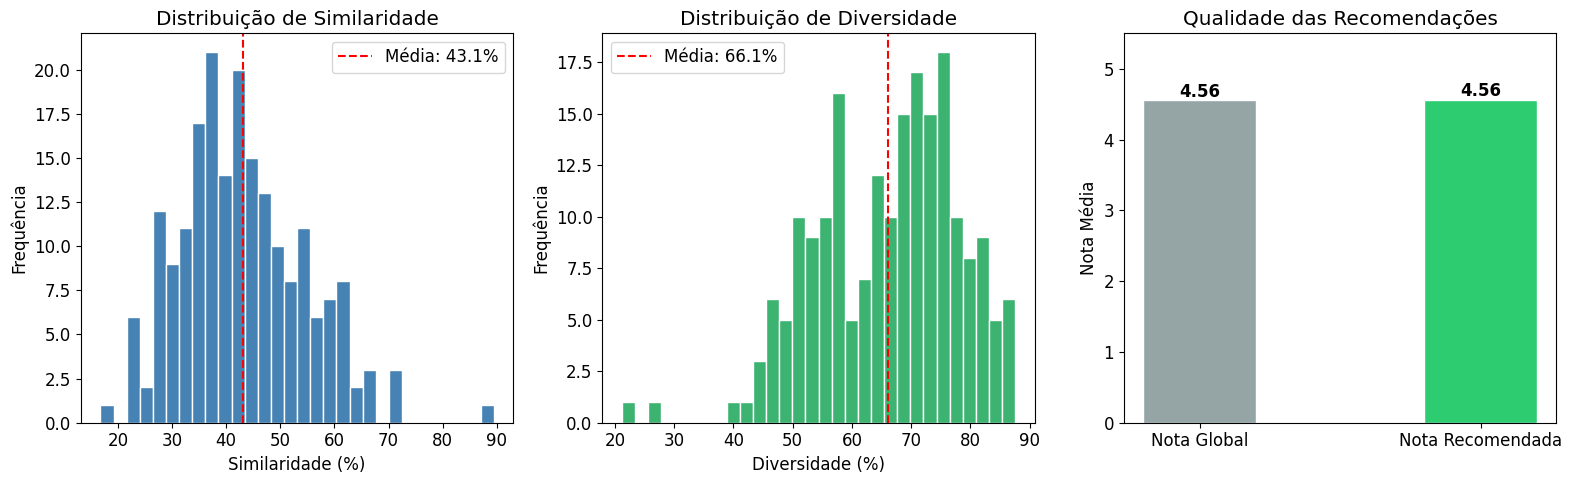

In [59]:
# Gráfico de métricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribuição de similaridade
axes[0].hist([s*100 for s in similarity_scores], bins=30,
             color='steelblue', edgecolor='white')
axes[0].axvline(sim_media, color='red', linestyle='--',
                label=f'Média: {sim_media:.1f}%')
axes[0].set_title('Distribuição de Similaridade')
axes[0].set_xlabel('Similaridade (%)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# 2. Distribuição de diversidade
axes[1].hist([d*100 for d in diversity_scores], bins=30,
             color='mediumseagreen', edgecolor='white')
axes[1].axvline(div_media, color='red', linestyle='--',
                label=f'Média: {div_media:.1f}%')
axes[1].set_title('Distribuição de Diversidade')
axes[1].set_xlabel('Diversidade (%)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

# 3. Nota recomendada vs global
categorias = ['Nota Global', 'Nota Recomendada']
valores    = [nota_global, nota_rec]
cores      = ['#95a5a6', '#2ecc71' if nota_rec >= nota_global else '#e74c3c']
bars = axes[2].bar(categorias, valores, color=cores, edgecolor='white', width=0.4)
axes[2].set_ylim(0, 5.5)
axes[2].set_title('Qualidade das Recomendações')
axes[2].set_ylabel('Nota Média')
for bar, val in zip(bars, valores):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Visualizações Finais

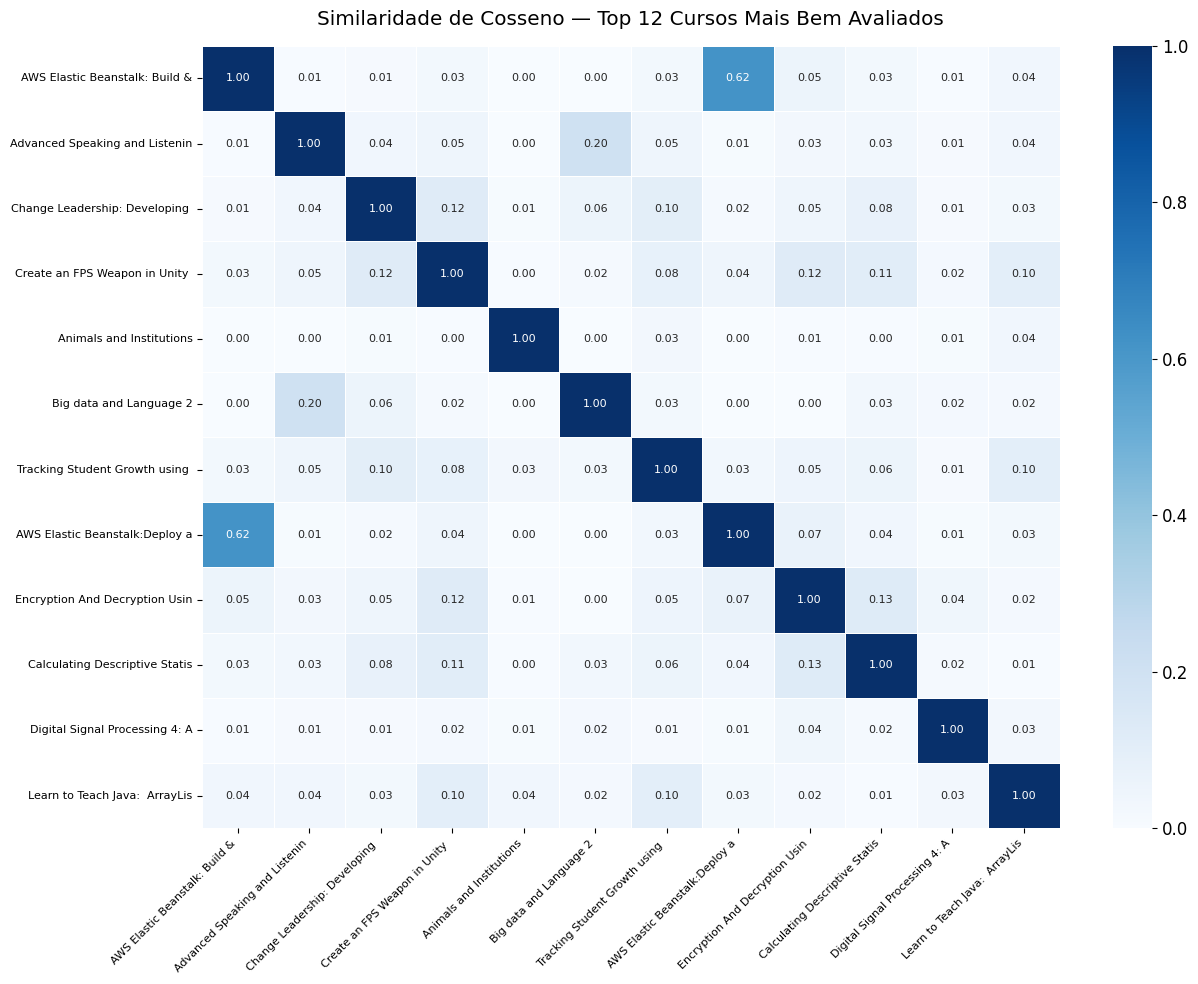

In [60]:
# Heatmap de similaridade entre os Top 12 cursos mais bem avaliados
top12 = df.nlargest(12, 'rating').reset_index(drop=True)
top12_idx = [df[df['name'] == name].index[0] for name in top12['name'] if name in df['name'].values]

if len(top12_idx) >= 5:
    top12_matrix = tfidf_matrix[top12_idx]
    sim = cosine_similarity(top12_matrix)
    labels = [df.iloc[i]['name'][:30] for i in top12_idx]

    plt.figure(figsize=(13, 10))
    sns.heatmap(sim, xticklabels=labels, yticklabels=labels,
                annot=True, fmt='.2f', cmap='Blues',
                linewidths=0.5, annot_kws={'size': 8},
                vmin=0, vmax=1)
    plt.title('Similaridade de Cosseno — Top 12 Cursos Mais Bem Avaliados', pad=15)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

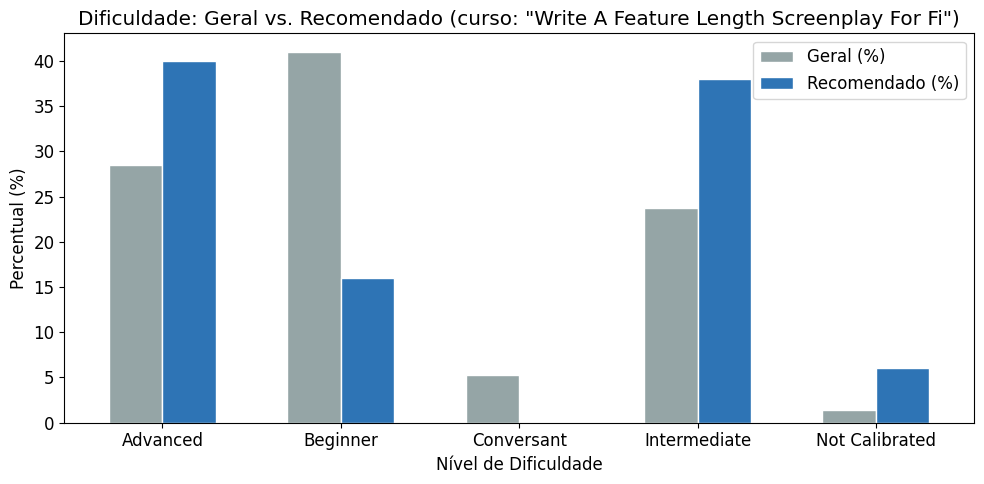

In [61]:
# Distribuição de dificuldade nas recomendações vs base geral
# (compara se o modelo privilegia algum nível de dificuldade)

QUERY_IDX = 0  # índice do curso de referência
distances, indices = model_knn.kneighbors(
    tfidf_matrix[QUERY_IDX], n_neighbors=50 + 1)
rec_diff = df.iloc[indices[0][1:]]['difficulty'].value_counts(normalize=True) * 100
all_diff = df['difficulty'].value_counts(normalize=True) * 100

diff_compare = pd.DataFrame({'Geral (%)': all_diff, 'Recomendado (%)': rec_diff}).fillna(0)

diff_compare.plot(kind='bar', figsize=(10, 5), color=['#95a5a6','#2E74B5'],
                  edgecolor='white', width=0.6)
plt.title(f'Dificuldade: Geral vs. Recomendado (curso: "{df.iloc[QUERY_IDX]["name"][:40]}")')
plt.xlabel('Nível de Dificuldade')
plt.ylabel('Percentual (%)')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# Resumo final
print('=' * 55)
print('  RESUMO DO SISTEMA DE RECOMENDAÇÃO KNN')
print('=' * 55)
print(f'  Dataset:              Coursera Courses 2021')
print(f'  Algoritmo:            KNN (Filtragem por Conteúdo)')
print(f'  Vetorização:          TF-IDF (Skills + Descrição)')
print(f'  Métrica:              Similaridade de Cosseno')
print(f'  K vizinhos:           {N_NEIGHBORS}')
print(f'  Total de cursos:      {len(df):,}')
print(f'  Vocabulário TF-IDF:   {tfidf_matrix.shape[1]:,} termos')
print(f'  Cobertura:            {cobertura:.1f}%')
print(f'  Similaridade média:   {sim_media:.1f}%')
print(f'  Diversidade média:    {div_media:.1f}%')
print(f'  Nota média rec.:      {nota_rec:.2f} (global: {nota_global:.2f})')
print('=' * 55)
print('  ODS 4 — Educação de Qualidade')
print('  ODS 8 — Trabalho Decente e Crescimento Econômico')
print('=' * 55)

  RESUMO DO SISTEMA DE RECOMENDAÇÃO KNN
  Dataset:              Coursera Courses 2021
  Algoritmo:            KNN (Filtragem por Conteúdo)
  Vetorização:          TF-IDF (Skills + Descrição)
  Métrica:              Similaridade de Cosseno
  K vizinhos:           10
  Total de cursos:      3,522
  Vocabulário TF-IDF:   5,000 termos
  Cobertura:            39.6%
  Similaridade média:   43.1%
  Diversidade média:    66.1%
  Nota média rec.:      4.56 (global: 4.56)
  ODS 4 — Educação de Qualidade
  ODS 8 — Trabalho Decente e Crescimento Econômico
